# 📘 3️⃣ Parámetros Más Importantes de PCA

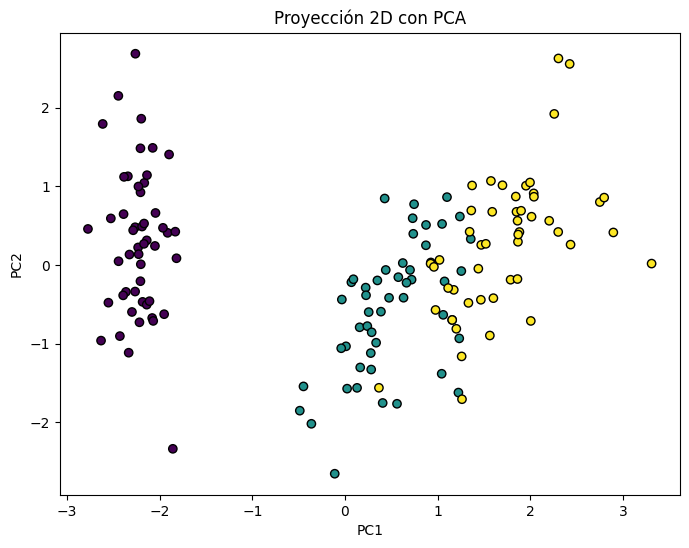

Varianza explicada: [0.72962445 0.22850762]
Varianza total: 0.9581320720000163


In [1]:
# ======================================================
# 🔹 PCA básico con Iris
# ======================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1️⃣ Cargar dataset
iris = sns.load_dataset("iris")
X = iris.drop(columns=["species"])

# 2️⃣ Escalar (MUY IMPORTANTE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ Visualización
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=pd.factorize(iris["species"])[0],
            cmap='viridis', edgecolors='k')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección 2D con PCA")
plt.show()

# 5️⃣ Varianza explicada
print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza total:", pca.explained_variance_ratio_.sum())


# 🔹 1) n_components

Define cuántos componentes conservar.

Valores posibles:
- Entero → número fijo
- Decimal entre 0 y 1 → porcentaje de varianza
- None → todos los componentes

Default: None

In [2]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Shape reducido:", X_pca.shape)
print("Varianza total:", pca.explained_variance_ratio_.sum())

Shape reducido: (150, 3)
Varianza total: 0.994821290892845


In [3]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Componentes elegidos:", pca.n_components_)
print("Varianza total:", pca.explained_variance_ratio_.sum())

Componentes elegidos: 2
Varianza total: 0.9581320720000163


# 🔹 2) svd_solver

Método matemático usado para calcular PCA.

Valores posibles:
- 'auto' (default)
- 'full'
- 'arpack'
- 'randomized' (más rápido para datasets grandes)

Default: 'auto'

In [4]:
pca = PCA(n_components=2, svd_solver="randomized")
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza total:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.72962445 0.22850762]
Varianza total: 0.9581320720000162


# 🔹 3) whiten

Si whiten=True:
- Escala los componentes para tener varianza unitaria.
- Puede ayudar antes de algunos modelos.
- Puede perder información relativa de escala.

Default: False

In [5]:
pca = PCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada:", pca.explained_variance_ratio_)
print("Varianza total:", pca.explained_variance_ratio_.sum())

Varianza explicada: [0.72962445 0.22850762]
Varianza total: 0.9581320720000163


# 🔹 4️⃣ Scree Plot

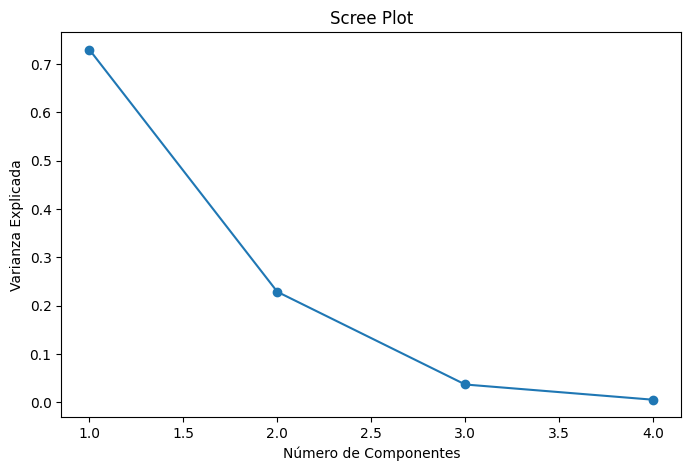

In [6]:
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker='o')

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada")
plt.title("Scree Plot")
plt.show()